J-1. Verifikasi lingkungan kerja

In [1]:
import sys
import platform
import multiprocessing
import os

print("Python   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib", "psutil"]:
    try:
        mod = __import__(nama)
        print(f"{nama:10s}:", mod.__version__)
    except ImportError:
        print(f"{nama:10s}: BELUM TERPASANG")

print("\nMemori:")
os.system("free -h")

print("\nDisk /content:")
os.system("df -h /content")

print("\nJava:")
os.system("java -version")

Python   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core : 2
pandas    : 2.2.3
numpy     : 2.1.3
pyarrow   : 23.0.1
matplotlib: 3.10.0
psutil    : 5.9.5

Memori:

Disk /content:

Java:


0

In [2]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       8.5Gi       2.1Mi       3.2Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


J-2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [4]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA   = "/content/data"
DIR_SIMPAN  = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print (os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['yellow_tripdata_2023-01.parquet', 'agregasi_per_jam.csv', 'pengukuran_kinerja.csv', 'agregasi_per_jam.parquet', 'distribusi_per_jam.png', 'studi_kasus_permintaan.png', 'studi_kasus_profitabilitas.png', 'bersih_snappy.parquet', 'bersih_gzip.parquet', 'green_tripdata_2023-02.parquet']


J-3. Pengukuran waktu dan memori

In [7]:
import time
import psutil

proses = psutil.Process(os.getpid())

catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2


def ukur(label, fungsi):

    mem_awal = rss_mb()
    waktu_awal = time.perf_counter()

    hasil = fungsi()

    waktu = (
        time.perf_counter()
        - waktu_awal
    )

    delta_memori = (
        rss_mb()
        - mem_awal
    )

    catatan.append({
        "langkah": label,
        "detik": round(waktu, 2),
        "delta_rss_mb": round(
            delta_memori,
            1
        )
    })

    print(
        f"[{label}] "
        f"{waktu:.2f} s | "
        f"RSS {delta_memori:+.1f} MB"
    )

    return hasil

In [6]:
import urllib.request

URL_GREEN = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/green_tripdata_2023-02.parquet"
)

PATH_GREEN = os.path.join(
    DIR_KERJA,
    "green_tripdata_2023-02.parquet"
)

if not os.path.exists(PATH_GREEN):

    print("Mengunduh dataset Green Taxi...")

    urllib.request.urlretrieve(
        URL_GREEN,
        PATH_GREEN
    )

    print("Download selesai.")

else:

    print("Dataset sudah tersedia.")

print(
    "Ukuran file:",
    round(
        os.path.getsize(PATH_GREEN) / 1024**2,
        2
    ),
    "MB"
)

Mengunduh dataset Green Taxi...
Download selesai.
Ukuran file: 1.46 MB


J-4. Membaca metadata Parquet

In [8]:
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile(
    PATH_GREEN
)

metadata = parquet_file.metadata

print("=== METADATA GREEN TAXI ===")

print(
    "Nama file   :",
    os.path.basename(PATH_GREEN)
)

print(
    "Jumlah baris:",
    f"{metadata.num_rows:,}"
)

print(
    "Jumlah kolom:",
    metadata.num_columns
)

print(
    "Row group   :",
    metadata.num_row_groups
)

print("\nNama kolom:")

for kolom in parquet_file.schema.names:
    print("-", kolom)

=== METADATA GREEN TAXI ===
Nama file   : green_tripdata_2023-02.parquet
Jumlah baris: 64,809
Jumlah kolom: 20
Row group   : 1

Nama kolom:
- VendorID
- lpep_pickup_datetime
- lpep_dropoff_datetime
- store_and_fwd_flag
- RatecodeID
- PULocationID
- DOLocationID
- passenger_count
- trip_distance
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- ehail_fee
- improvement_surcharge
- total_amount
- payment_type
- trip_type
- congestion_surcharge


In [10]:
import pandas as pd

df = ukur(
    "membaca Green Taxi",
    lambda: pd.read_parquet(
        PATH_GREEN
    )
)

print("Dimensi dataset:", df.shape)

print("\nSchema:")

print(df.dtypes)

[membaca Green Taxi] 0.02 s | RSS +10.6 MB
Dimensi dataset: (64809, 20)

Schema:
VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
dtype: object


J-5. Memilih kolom yang dibutuhkan

In [11]:
kolom_analisis = [
    "lpep_pickup_datetime",
    "lpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

df = ukur(
    "membaca kolom analisis",
    lambda: pd.read_parquet(
        PATH_GREEN,
        columns=kolom_analisis
    )
)

print("Dimensi:", df.shape)

display(df.head())

[membaca kolom analisis] 0.01 s | RSS -8.1 MB
Dimensi: (64809, 8)


,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-02-01 00:46:22,2023-02-01 01:05:57,1.0,10.80,2.0,42.9,0.00,45.40
1,2023-02-01 00:05:09,2023-02-01 00:22:42,1.0,4.76,2.0,23.3,0.00,25.80
2,2023-02-01 00:03:47,2023-02-01 00:27:30,1.0,6.32,1.0,30.3,8.89,44.44
3,2023-01-31 23:30:56,2023-01-31 23:51:40,1.0,3.50,2.0,16.3,0.00,21.55
4,2023-02-01 00:15:05,2023-02-01 00:26:02,1.0,3.14,2.0,17.0,0.00,19.50


In [12]:
memori_sebelum = (
    df.memory_usage(
        deep=True
    ).sum()
    / 1024**2
)

df["passenger_count"] = pd.to_numeric(
    df["passenger_count"],
    downcast="float"
)

df["payment_type"] = pd.to_numeric(
    df["payment_type"],
    errors="coerce"
).fillna(0).astype("int8")

for kolom in [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]:

    df[kolom] = pd.to_numeric(
        df[kolom],
        downcast="float"
    )

memori_sesudah = (
    df.memory_usage(
        deep=True
    ).sum()
    / 1024**2
)

print(
    f"Memori sebelum optimasi : "
    f"{memori_sebelum:.2f} MB"
)

print(
    f"Memori setelah optimasi : "
    f"{memori_sesudah:.2f} MB"
)

print(
    f"Penghematan             : "
    f"{memori_sebelum - memori_sesudah:.2f} MB"
)

Memori sebelum optimasi : 3.96 MB
Memori setelah optimasi : 2.53 MB
Penghematan             : 1.42 MB


J-6. Pemeriksaan kualitas data dan pembersihan

In [13]:
df["lpep_pickup_datetime"] = pd.to_datetime(
    df["lpep_pickup_datetime"]
)

df["lpep_dropoff_datetime"] = pd.to_datetime(
    df["lpep_dropoff_datetime"]
)

In [14]:
df["durasi_menit"] = (
    df["lpep_dropoff_datetime"]
    - df["lpep_pickup_datetime"]
).dt.total_seconds() / 60

In [15]:
print("=== Statistik Data ===")

display(
    df[
        [
            "trip_distance",
            "durasi_menit",
            "total_amount"
        ]
    ].describe()
)

=== Statistik Data ===


,trip_distance,durasi_menit,total_amount
count,64809.000000,64809.000000,64809.000000
mean,13.696354,17.744897,21.884577
std,931.311966,69.280970,14.721561
min,0.000000,0.000000,-94.839996
25%,1.130000,7.250000,12.960000
50%,1.890000,11.500000,18.000000
75%,3.350000,17.783333,26.320000
max,178919.980000,1439.633333,441.000000


In [16]:
print("=== Nilai Kosong ===")

display(
    df.isna().sum()
)

=== Nilai Kosong ===


,0
lpep_pickup_datetime,0
lpep_dropoff_datetime,0
passenger_count,4821
trip_distance,0
payment_type,0
fare_amount,0
tip_amount,0
total_amount,0
durasi_menit,0


In [17]:
print("=== Data Anomali ===")

anomali = {
    "trip_distance <= 0":
        (df["trip_distance"] <= 0).sum(),

    "durasi <= 0":
        (df["durasi_menit"] <= 0).sum(),

    "durasi > 180 menit":
        (df["durasi_menit"] > 180).sum(),

    "total_amount <= 0":
        (df["total_amount"] <= 0).sum()
}

for nama, jumlah in anomali.items():

    persentase = (
        jumlah / len(df) * 100
    )

    print(
        f"{nama:25s}: "
        f"{jumlah:,} "
        f"({persentase:.2f}%)"
    )

=== Data Anomali ===
trip_distance <= 0       : 2,857 (4.41%)
durasi <= 0              : 81 (0.12%)
durasi > 180 menit       : 224 (0.35%)
total_amount <= 0        : 270 (0.42%)


In [18]:
data_bersih = df[
    (df["trip_distance"] > 0)
    &
    (df["trip_distance"] < 100)
    &
    (df["durasi_menit"].between(
        1,
        180
    ))
    &
    (df["total_amount"] > 0)
].copy()

print(
    f"Data awal  : {len(df):,} baris"
)

print(
    f"Data bersih: {len(data_bersih):,} baris"
)

print(
    f"Dihapus    : "
    f"{len(df) - len(data_bersih):,} baris"
)

Data awal  : 64,809 baris
Data bersih: 61,007 baris
Dihapus    : 3,802 baris


In [19]:
top5 = (
    data_bersih
    .nlargest(
        5,
        "trip_distance"
    )
)

print(
    "=== 5 Trip Distance Terbesar ==="
)

display(top5)

=== 5 Trip Distance Terbesar ===


,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit
7937,2023-02-04 13:06:08,2023-02-04 14:55:30,6.0,88.47,1,319.399994,0.000000,322.350006,109.366667
61226,2023-02-07 15:29:00,2023-02-07 16:59:00,NaN,54.19,0,181.300003,13.430000,208.479996,90.000000
29100,2023-02-14 14:27:16,2023-02-14 15:29:58,1.0,49.40,2,90.000000,0.000000,102.750000,62.700000
37782,2023-02-18 04:28:46,2023-02-18 05:48:13,1.0,47.57,2,189.199997,0.000000,191.699997,79.450000
54399,2023-02-26 08:43:43,2023-02-26 09:33:01,1.0,44.50,1,100.000000,20.299999,121.800003,49.300000


J-7. Menulis data ke CSV

In [20]:
PATH_CSV = os.path.join(
    DIR_KERJA,
    "green_bersih.csv"
)

ukur(
    "menulis CSV Green",
    lambda: data_bersih.to_csv(
        PATH_CSV,
        index=False
    )
)

print(
    "File CSV:",
    PATH_CSV
)

[menulis CSV Green] 0.40 s | RSS +3.6 MB
File CSV: /content/data/green_bersih.csv


In [21]:
def agregasi_chunking(
    path,
    ukuran_chunk
):

    jumlah_baris = 0
    total_amount = 0
    per_jam = {}

    chunks = pd.read_csv(
        path,
        usecols=[
            "lpep_pickup_datetime",
            "total_amount"
        ],
        parse_dates=[
            "lpep_pickup_datetime"
        ],
        chunksize=ukuran_chunk
    )

    for chunk in chunks:

        jumlah_baris += len(chunk)

        total_amount += (
            chunk["total_amount"].sum()
        )

        jam_data = (
            chunk[
                "lpep_pickup_datetime"
            ].dt.hour
        )

        for jam, bagian in chunk.groupby(
            jam_data
        ):

            jumlah, total = per_jam.get(
                jam,
                (0, 0)
            )

            per_jam[jam] = (
                jumlah + len(bagian),
                total
                + bagian["total_amount"].sum()
            )

    return (
        jumlah_baris,
        total_amount,
        per_jam
    )

In [22]:
hasil_100k = ukur(
    "chunking 100000",
    lambda: agregasi_chunking(
        PATH_CSV,
        100_000
    )
)

print(
    "Jumlah baris:",
    f"{hasil_100k[0]:,}"
)

print(
    "Total amount:",
    hasil_100k[1]
)

[chunking 100000] 0.08 s | RSS +1.5 MB
Jumlah baris: 61,007
Total amount: 1334499.4200000002


In [23]:
hasil_1m = ukur(
    "chunking 1000000",
    lambda: agregasi_chunking(
        PATH_CSV,
        1_000_000
    )
)

print(
    "Jumlah baris:",
    f"{hasil_1m[0]:,}"
)

print(
    "Total amount:",
    hasil_1m[1]
)

[chunking 1000000] 0.10 s | RSS +0.0 MB
Jumlah baris: 61,007
Total amount: 1334499.4200000002


J-8. Instalasi dan inisialisasi PySpark

In [25]:
!pip install -q pyspark==3.5.1

In [26]:
from pyspark.sql import (
    SparkSession,
    functions as F
)

spark = (
    SparkSession.builder
    .appName("Green-Taxi-Analysis")
    .master("local[*]")
    .config(
        "spark.driver.memory",
        "4g"
    )
    .config(
        "spark.sql.shuffle.partitions",
        "8"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel(
    "WARN"
)

print(
    "Spark version:",
    spark.version
)

Spark version: 3.5.1


In [27]:
sdf = spark.read.parquet(
    PATH_GREEN
)

sdf.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- lpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- trip_type: long (nullable = true)
 |-- congestion_surcharge: double (nullable = true)



In [28]:
jumlah_spark = ukur(
    "Spark count",
    lambda: sdf.count()
)


print(
    "Jumlah baris:",
    f"{jumlah_spark:,}"
)

[Spark count] 1.64 s | RSS +0.0 MB
Jumlah baris: 64,809


In [29]:
sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(
                "lpep_dropoff_datetime"
            )
            -
            F.unix_timestamp(
                "lpep_pickup_datetime"
            )
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0)
        &
        (F.col("trip_distance") < 100)
    )
    .filter(
        F.col(
            "durasi_menit"
        ).between(
            1,
            180
        )
    )
    .filter(
        F.col("total_amount") > 0
    )
)

In [31]:
hasil_spark = (
    sdf_bersih

    .withColumn(
        "jam",
        F.hour(
            "lpep_pickup_datetime"
        )
    )

    .groupBy("jam")

    .agg(
        F.count("*").alias(
            "jumlah_perjalanan"
        ),

        F.round(
            F.avg("trip_distance"),
            2
        ).alias(
            "rata_jarak"
        ),

        F.round(
            F.avg("durasi_menit"),
            2
        ).alias(
            "rata_durasi"
        ),

        F.round(
            F.avg("total_amount"),
            2
        ).alias(
            "rata_tarif"
        )
    )

    .orderBy("jam")
)

ukur(
    "Spark agregasi per jam",
    lambda: hasil_spark.show(
        24,
        truncate=False
    )
)

+---+-----------------+----------+-----------+----------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|
+---+-----------------+----------+-----------+----------+
|0  |1079             |3.35      |12.97      |21.76     |
|1  |711              |3.38      |13.12      |22.04     |
|2  |574              |3.65      |14.02      |24.13     |
|3  |433              |3.95      |14.84      |24.49     |
|4  |379              |4.45      |14.79      |27.29     |
|5  |307              |5.2       |15.81      |29.35     |
|6  |847              |3.31      |11.77      |20.99     |
|7  |2267             |3.01      |14.06      |21.44     |
|8  |2834             |3.04      |15.36      |21.77     |
|9  |3136             |2.91      |14.2       |21.17     |
|10 |3147             |3.09      |14.2       |21.69     |
|11 |3269             |3.02      |14.29      |21.67     |
|12 |3207             |3.01      |14.3       |21.59     |
|13 |3569             |3.03      |14.76      |21.84     |
|14 |3872     

In [32]:
hasil_tip = (
    sdf_bersih

    .withColumn(
        "persen_tip",

        F.when(
            F.col("fare_amount") != 0,

            F.col("tip_amount")
            /
            F.col("fare_amount")
            * 100

        ).otherwise(None)
    )

    .groupBy(
        "payment_type"
    )

    .agg(
        F.count("*").alias(
            "jumlah_transaksi"
        ),

        F.round(
            F.avg("persen_tip"),
            2
        ).alias(
            "rata_persen_tip"
        )
    )

    .orderBy(
        "payment_type"
    )
)

hasil_tip.show()

+------------+----------------+---------------+
|payment_type|jumlah_transaksi|rata_persen_tip|
+------------+----------------+---------------+
|        NULL|            4626|          15.38|
|           1|           36264|          22.04|
|           2|           19895|            0.0|
|           3|             179|            0.0|
|           4|              43|            0.0|
+------------+----------------+---------------+



J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [33]:
data_bersih["jam"] = (
    data_bersih[
        "lpep_pickup_datetime"
    ].dt.hour
)
agregasi = (
    data_bersih

    .groupby("jam")

    .agg(
        jumlah_perjalanan=(
            "total_amount",
            "size"
        ),

        rata_jarak=(
            "trip_distance",
            "mean"
        ),

        rata_durasi=(
            "durasi_menit",
            "mean"
        ),

        rata_tarif=(
            "total_amount",
            "mean"
        ),

        median_tarif=(
            "total_amount",
            "median"
        )
    )

    .round(2)

    .reset_index()
)

display(agregasi)

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,1079,3.35,12.97,21.760000,17.400000
1,1,711,3.38,13.12,22.040001,17.520000
2,2,574,3.65,14.02,24.129999,19.200001
3,3,433,3.95,14.84,24.490000,18.799999
4,4,379,4.45,14.79,27.290001,21.719999
5,5,307,5.20,15.81,29.350000,22.950001
6,6,847,3.31,11.77,20.990000,15.850000
7,7,2267,3.01,14.06,21.440001,17.049999
8,8,2834,3.04,15.36,21.770000,17.400000
9,9,3136,2.91,14.20,21.170000,17.610001


In [35]:
sdf_bersih.createOrReplaceTempView(
    "green_trips"
)
hasil_sql = spark.sql(
    """
    SELECT
        HOUR(lpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan,
        ROUND(
            AVG(trip_distance),
            2
        ) AS rata_jarak,
        ROUND(
            AVG(durasi_menit),
            2
        ) AS rata_durasi,
        ROUND(
            AVG(total_amount),
            2
        ) AS rata_tarif
    FROM green_trips
    GROUP BY
        HOUR(lpep_pickup_datetime)
    ORDER BY jam
    """
)

hasil_sql.show(24)

+---+-----------------+----------+-----------+----------+
|jam|jumlah_perjalanan|rata_jarak|rata_durasi|rata_tarif|
+---+-----------------+----------+-----------+----------+
|  0|             1079|      3.35|      12.97|     21.76|
|  1|              711|      3.38|      13.12|     22.04|
|  2|              574|      3.65|      14.02|     24.13|
|  3|              433|      3.95|      14.84|     24.49|
|  4|              379|      4.45|      14.79|     27.29|
|  5|              307|       5.2|      15.81|     29.35|
|  6|              847|      3.31|      11.77|     20.99|
|  7|             2267|      3.01|      14.06|     21.44|
|  8|             2834|      3.04|      15.36|     21.77|
|  9|             3136|      2.91|       14.2|     21.17|
| 10|             3147|      3.09|       14.2|     21.69|
| 11|             3269|      3.02|      14.29|     21.67|
| 12|             3207|      3.01|       14.3|     21.59|
| 13|             3569|      3.03|      14.76|     21.84|
| 14|         

In [36]:
sql_df = hasil_sql.toPandas()
validasi = (
    agregasi[
        [
            "jam",
            "jumlah_perjalanan"
        ]
    ]

    .merge(
        sql_df[
            [
                "jam",
                "jumlah_perjalanan"
            ]
        ],

        on="jam",

        suffixes=(
            "_pandas",
            "_spark_sql"
        ),

        how="outer"
    )

    .fillna(0)
)

validasi["selisih"] = (
    validasi[
        "jumlah_perjalanan_pandas"
    ]
    -
    validasi[
        "jumlah_perjalanan_spark_sql"
    ]
).abs()

display(validasi)

,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,1079,1079,0
1,1,711,711,0
2,2,574,574,0
3,3,433,433,0
4,4,379,379,0
5,5,307,307,0
6,6,847,847,0
7,7,2267,2267,0
8,8,2834,2834,0
9,9,3136,3136,0


In [37]:
selisih_maksimum = (
    validasi["selisih"].max()
)

print(
    "Selisih maksimum:",
    selisih_maksimum
)

if selisih_maksimum == 0:

    print(
        "Hasil konsisten: "
        "Pandas dan Spark SQL sama."
    )

else:

    print(
        "Terdapat perbedaan hasil."
    )

Selisih maksimum: 0
Hasil konsisten: Pandas dan Spark SQL sama.


In [43]:
PATH_SNAPPY = os.path.join(
    "green_bersih_snappy.parquet"
)

PATH_GZIP = os.path.join(
    "green_bersih_gzip.parquet"
)
ukur(
    "Parquet Snappy",

    lambda: data_bersih.to_parquet(
        PATH_SNAPPY,
        index=False,
        compression="snappy"
    )
)
ukur(
    "Parquet Gzip",

    lambda: data_bersih.to_parquet(
        PATH_GZIP,
        index=False,
        compression="gzip"
    )
)
ukuran_snappy = (
    os.path.getsize(
        PATH_SNAPPY
    ) / 1024**2
)

ukuran_gzip = (
    os.path.getsize(
        PATH_GZIP
    ) / 1024**2
)

print(
    f"Snappy : {ukuran_snappy:.2f} MB"
)

print(
    f"Gzip   : {ukuran_gzip:.2f} MB"
)

[Parquet Snappy] 0.04 s | RSS -6.9 MB
[Parquet Gzip] 0.82 s | RSS +5.8 MB
Snappy : 1.47 MB
Gzip   : 1.14 MB


In [44]:
PATH_KINERJA = os.path.join(
    "pengukuran_kinerja.csv"
)

df_kinerja = pd.DataFrame(
    catatan
)

df_kinerja.to_csv(
    PATH_KINERJA,
    index=False
)

display(df_kinerja)

,langkah,detik,delta_rss_mb
0,membaca Green Taxi,0.23,30.5
1,membaca Green Taxi,0.02,10.6
2,membaca kolom analisis,0.01,-8.1
3,menulis CSV Green,0.40,3.6
4,chunking 100000,0.08,1.5
5,chunking 1000000,0.10,0.0
6,Spark count,1.64,0.0
7,Spark agregasi per jam,2.96,0.0
8,Parquet Snappy,0.04,-6.9
9,Parquet Gzip,0.82,5.8


In [45]:
termahal = (
    df_kinerja
    .sort_values(
        "detik",
        ascending=False
    )
    .iloc[0]
)

print(
    "=== LANGKAH PALING MAHAL ==="
)

print(
    "Langkah:",
    termahal["langkah"]
)

print(
    "Waktu  :",
    termahal["detik"],
    "detik"
)

print(
    "Memory :",
    termahal["delta_rss_mb"],
    "MB"
)

=== LANGKAH PALING MAHAL ===
Langkah: Spark agregasi per jam
Waktu  : 2.96 detik
Memory : 0.0 MB


J-10. Visualisasi hasil

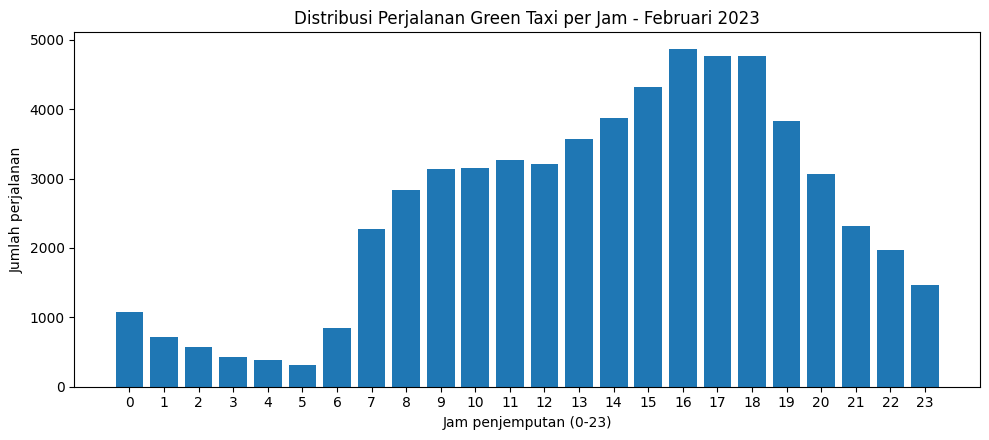

Grafik tersimpan: distribusi_perjalanan_per_jam.png


In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

ax.bar(
    agregasi["jam"],
    agregasi[
        "jumlah_perjalanan"
    ]
)

ax.set_xlabel(
    "Jam penjemputan (0-23)"
)

ax.set_ylabel(
    "Jumlah perjalanan"
)

ax.set_title(
    "Distribusi Perjalanan Green Taxi "
    "per Jam - Februari 2023"
)

ax.set_xticks(
    range(0, 24)
)

fig.tight_layout()

PATH_GRAFIK = os.path.join(
    "distribusi_perjalanan_per_jam.png"
)

fig.savefig(
    PATH_GRAFIK,
    dpi=150
)

plt.show()

print(
    "Grafik tersimpan:",
    PATH_GRAFIK
)

In [48]:
jam_tertinggi = (
    agregasi
    .loc[
        agregasi[
            "jumlah_perjalanan"
        ].idxmax()
    ]
)

print(
    "=== JAM TERSIBUK ==="
)

print(
    "Jam:",
    int(
        jam_tertinggi["jam"]
    )
)

print(
    "Jumlah perjalanan:",
    int(
        jam_tertinggi[
            "jumlah_perjalanan"
        ]
    )
)

=== JAM TERSIBUK ===
Jam: 16
Jumlah perjalanan: 4866


In [49]:
print("=== PEMERIKSAAN AKHIR ===")

file_hasil = [
    PATH_CSV,
    PATH_SNAPPY,
    PATH_GZIP,
    PATH_KINERJA,
    PATH_GRAFIK
]

for path in file_hasil:

    status = (
        "OK"
        if os.path.exists(path)
        else "GAGAL"
    )

    print(
        f"{os.path.basename(path):45s}: {status}"
    )

print(
    "\nJumlah data awal :",
    f"{len(df):,}"
)

print(
    "Jumlah data bersih:",
    f"{len(data_bersih):,}"
)

print(
    "Selisih Pandas vs Spark SQL:",
    selisih_maksimum
)

=== PEMERIKSAAN AKHIR ===
green_bersih.csv                             : OK
green_bersih_snappy.parquet                  : OK
green_bersih_gzip.parquet                    : OK
pengukuran_kinerja.csv                       : OK
distribusi_perjalanan_per_jam.png            : OK

Jumlah data awal : 64,809
Jumlah data bersih: 61,007
Selisih Pandas vs Spark SQL: 0


Melihat perbandingan yellow taxi dan green taxi

In [55]:
import pandas as pd
import matplotlib.pyplot as plt


In [59]:
import requests
import os

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

os.makedirs("/content/praktikum_bigdata", exist_ok=True)

response = requests.get(url)

with open("/content/praktikum_bigdata/yellow_tripdata_2023-01.parquet", "wb") as f:
    f.write(response.content)

print("File Yellow Taxi berhasil di-download.")

File Yellow Taxi berhasil di-download.


In [61]:
import os

print(os.path.exists(
    "/content/praktikum_bigdata/yellow_tripdata_2023-01.parquet"
))

True


In [62]:
yellow = pd.read_parquet(
    "/content/praktikum_bigdata/yellow_tripdata_2023-01.parquet"
)

yellow = yellow[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "fare_amount",
        "total_amount"
    ]
].copy()

yellow.rename(
    columns={
        "tpep_pickup_datetime": "pickup_datetime",
        "tpep_dropoff_datetime": "dropoff_datetime"
    },
    inplace=True
)

yellow["pickup_datetime"] = pd.to_datetime(
    yellow["pickup_datetime"]
)

yellow["dropoff_datetime"] = pd.to_datetime(
    yellow["dropoff_datetime"]
)

yellow["durasi_menit"] = (
    yellow["dropoff_datetime"] -
    yellow["pickup_datetime"]
).dt.total_seconds() / 60

In [63]:
yellow_bersih = yellow[
    (yellow["trip_distance"] > 0) &
    (yellow["trip_distance"] < 100) &
    (yellow["durasi_menit"].between(1, 180)) &
    (yellow["total_amount"] > 0)
].copy()

yellow_bersih["jam"] = (
    yellow_bersih["pickup_datetime"].dt.hour
)

In [64]:
agregasi_yellow = (
    yellow_bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("trip_distance", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("fare_amount", "mean")
    )
    .reset_index()
)

In [66]:
import requests
import os

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-02.parquet"

os.makedirs("/content/praktikum_bigdata", exist_ok=True)

response = requests.get(url)

with open("/content/praktikum_bigdata/green_tripdata_2023-02.parquet", "wb") as f:
    f.write(response.content)

print("File Green Taxi berhasil di-download.")

File Green Taxi berhasil di-download.


In [67]:
green = pd.read_parquet(
    "/content/praktikum_bigdata/green_tripdata_2023-02.parquet"
)

green = green[
    [
        "lpep_pickup_datetime",
        "lpep_dropoff_datetime",
        "trip_distance",
        "fare_amount",
        "total_amount"
    ]
].copy()

green.rename(
    columns={
        "lpep_pickup_datetime": "pickup_datetime",
        "lpep_dropoff_datetime": "dropoff_datetime"
    },
    inplace=True
)

green["pickup_datetime"] = pd.to_datetime(
    green["pickup_datetime"]
)

green["dropoff_datetime"] = pd.to_datetime(
    green["dropoff_datetime"]
)

green["durasi_menit"] = (
    green["dropoff_datetime"] -
    green["pickup_datetime"]
).dt.total_seconds() / 60

In [68]:
green_bersih = green[
    (green["trip_distance"] > 0) &
    (green["trip_distance"] < 100) &
    (green["durasi_menit"].between(1, 180)) &
    (green["total_amount"] > 0)
].copy()

green_bersih["jam"] = (
    green_bersih["pickup_datetime"].dt.hour
)

In [69]:
agregasi_green = (
    green_bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("trip_distance", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("fare_amount", "mean")
    )
    .reset_index()
)

In [70]:
semua_jam = pd.DataFrame({
    "jam": range(24)
})

agregasi_yellow = (
    semua_jam
    .merge(agregasi_yellow, on="jam", how="left")
    .fillna(0)
)

agregasi_green = (
    semua_jam
    .merge(agregasi_green, on="jam", how="left")
    .fillna(0)
)


In [71]:
perbandingan = agregasi_yellow[
    ["jam", "jumlah_perjalanan", "rata_jarak",
     "rata_durasi", "rata_tarif"]
].merge(
    agregasi_green[
        ["jam", "jumlah_perjalanan", "rata_jarak",
         "rata_durasi", "rata_tarif"]
    ],
    on="jam",
    suffixes=("_yellow", "_green")
)

In [72]:
perbandingan["selisih_perjalanan"] = (
    perbandingan["jumlah_perjalanan_yellow"] -
    perbandingan["jumlah_perjalanan_green"]
)

perbandingan["persentase_perbedaan"] = (
    abs(perbandingan["selisih_perjalanan"]) /
    perbandingan["jumlah_perjalanan_green"].replace(0, pd.NA)
) * 100

perbandingan = perbandingan.round(2)

In [73]:
print("=== PERBANDINGAN YELLOW TAXI DAN GREEN TAXI ===")

display(perbandingan)

=== PERBANDINGAN YELLOW TAXI DAN GREEN TAXI ===


,jam,jumlah_perjalanan_yellow,rata_jarak_yellow,rata_durasi_yellow,rata_tarif_yellow,jumlah_perjalanan_green,rata_jarak_green,rata_durasi_green,rata_tarif_green,selisih_perjalanan,persentase_perbedaan
0,0,82289,4.04,13.57,19.81,1079,3.35,12.97,16.98,81210,7526.41
1,1,57766,3.53,12.63,17.96,711,3.38,13.12,17.25,57055,8024.61
2,2,40445,3.28,12.07,16.95,574,3.65,14.02,18.79,39871,6946.17
3,3,26146,3.58,12.15,17.95,433,3.95,14.84,19.49,25713,5938.34
4,4,16618,4.79,13.52,22.44,379,4.45,14.79,21.79,16239,4284.70
5,5,16940,6.03,14.70,26.49,307,5.20,15.81,23.42,16633,5417.92
6,6,42300,4.80,14.49,22.17,847,3.31,11.77,16.12,41453,4894.10
7,7,84569,3.69,14.42,18.97,2267,3.01,14.06,16.71,82302,3630.44
8,8,114064,3.08,14.33,17.50,2834,3.04,15.36,16.98,111230,3924.84
9,9,127988,3.09,14.23,17.60,3136,2.91,14.20,16.33,124852,3981.25


In [74]:
jam_tertinggi_yellow = perbandingan.loc[
    perbandingan["jumlah_perjalanan_yellow"].idxmax()
]

jam_tertinggi_green = perbandingan.loc[
    perbandingan["jumlah_perjalanan_green"].idxmax()
]

total_yellow = perbandingan[
    "jumlah_perjalanan_yellow"
].sum()

total_green = perbandingan[
    "jumlah_perjalanan_green"
].sum()

print("=== RINGKASAN ===")

print(
    f"Total perjalanan Yellow Taxi : {total_yellow:,}"
)

print(
    f"Total perjalanan Green Taxi  : {total_green:,}"
)

print(
    f"Jam tersibuk Yellow Taxi     : "
    f"{int(jam_tertinggi_yellow['jam']):02d}.00 "
    f"({int(jam_tertinggi_yellow['jumlah_perjalanan_yellow']):,} perjalanan)"
)

print(
    f"Jam tersibuk Green Taxi      : "
    f"{int(jam_tertinggi_green['jam']):02d}.00 "
    f"({int(jam_tertinggi_green['jumlah_perjalanan_green']):,} perjalanan)"
)

=== RINGKASAN ===
Total perjalanan Yellow Taxi : 2,986,911
Total perjalanan Green Taxi  : 61,007
Jam tersibuk Yellow Taxi     : 18.00 (210,858 perjalanan)
Jam tersibuk Green Taxi      : 16.00 (4,866 perjalanan)


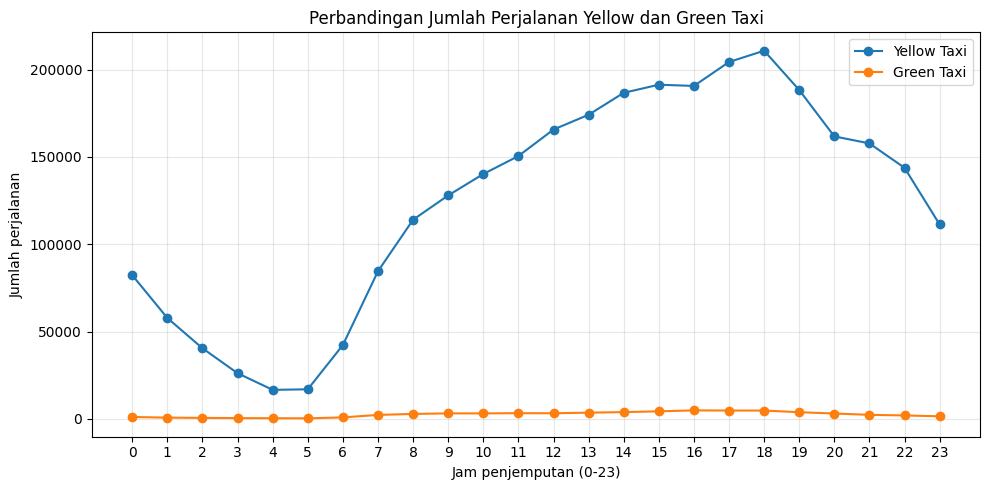

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(
    perbandingan["jam"],
    perbandingan["jumlah_perjalanan_yellow"],
    marker="o",
    label="Yellow Taxi"
)

plt.plot(
    perbandingan["jam"],
    perbandingan["jumlah_perjalanan_green"],
    marker="o",
    label="Green Taxi"
)

plt.xlabel("Jam penjemputan (0-23)")
plt.ylabel("Jumlah perjalanan")
plt.title(
    "Perbandingan Jumlah Perjalanan Yellow dan Green Taxi"
)

plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
tabel_laporan = perbandingan[
    [
        "jam",
        "jumlah_perjalanan_yellow",
        "jumlah_perjalanan_green",
        "selisih_perjalanan"
    ]
].copy()

tabel_laporan.columns = [
    "Jam",
    "Yellow Taxi",
    "Green Taxi",
    "Selisih"
]

display(tabel_laporan)

,Jam,Yellow Taxi,Green Taxi,Selisih
0,0,82289,1079,81210
1,1,57766,711,57055
2,2,40445,574,39871
3,3,26146,433,25713
4,4,16618,379,16239
5,5,16940,307,16633
6,6,42300,847,41453
7,7,84569,2267,82302
8,8,114064,2834,111230
9,9,127988,3136,124852
